In [2]:
from IPython.display import Markdown, display

In [3]:
display(Markdown("""
<span style="font-size:16px;">

## DSM050 CW1, 20-07-2026

### mcPHASES: A Dataset of Physiological, Hormonal, and Self-reported Events and Symptoms for Menstrual Health Tracking with Wearables

###  Exercise and Menstrual Pain: An Exploratory Data Analysis



"""))


<span style="font-size:16px;">

## DSM050 CW1, 20-07-2026

### mcPHASES: A Dataset of Physiological, Hormonal, and Self-reported Events and Symptoms for Menstrual Health Tracking with Wearables

###  Exercise and Menstrual Pain: An Exploratory Data Analysis





In [4]:
import os
os.getcwd()

'/Users/lucameoli'

In [5]:
#first of all I will work with subject-info dataset
import pandas as pd
df = pd.read_csv(
    'subject-info.csv')
df.head()

,id,birth_year,gender,ethnicity,education,sexually_active,self_report_menstrual_health_literacy,age_of_first_menarche
0,1,1999,Woman,White,"Some university/ post-secondary, no degree",Yes,NaN,14
1,2,1995,Woman,East Asian,"Bachelor's degree (e.g. BA, BS)",Yes,High,13
2,3,2000,Woman,East Asian,"Bachelor's degree (e.g. BA, BS)",No,High,12
3,4,2000,Woman,South Asian,Doctorate or professional degree,No,Medium,12
4,6,1997,Woman,East Asian,Doctorate or professional degree,Yes,Low,13


In [6]:
#As a first thing I check on missing values
df.isnull().sum()

id                                       0
birth_year                               0
gender                                   0
ethnicity                                0
education                                0
sexually_active                          0
self_report_menstrual_health_literacy    1
age_of_first_menarche                    0
dtype: int64

In [7]:
#there is only one missing value and it is for self_report_menstrual_health_literacy...
#this will be ignored for the descriptive cohort analysis, as one missing entry 
#does not significantly impact the overall results

In [8]:
#I check on the type of variables that are present
df.dtypes

id                                        int64
birth_year                                int64
gender                                   object
ethnicity                                object
education                                object
sexually_active                          object
self_report_menstrual_health_literacy    object
age_of_first_menarche                     int64
dtype: object

In [9]:
df['id'].nunique()
#n subjects

42

In [10]:
print(
    df['ethnicity'].value_counts(), "\n\n",
   df['education'].value_counts(), "\n\n",
  df['sexually_active'].value_counts(), "\n\n",
  df['self_report_menstrual_health_literacy'].value_counts(), "\n\n",
  df['age_of_first_menarche'].value_counts()
)

ethnicity
East Asian         14
Southeast Asian    10
White               9
Middle Eastern      5
South Asian         1
African             1
Latina              1
Caribbean           1
Name: count, dtype: int64 

 education
Some university/ post-secondary, no degree     21
Bachelor's degree (e.g. BA, BS)                10
High school degree or equivalent (e.g. GED)     6
Doctorate or professional degree                3
Master's degree (e.g. MA, MS, MEd)              2
Name: count, dtype: int64 

 sexually_active
No                   24
Yes                  15
Prefer not to say     3
Name: count, dtype: int64 

 self_report_menstrual_health_literacy
Medium          23
High            12
Low              4
Expert           1
Non-existent     1
Name: count, dtype: int64 

 age_of_first_menarche
12    19
11     8
13     6
10     5
14     3
15     1
Name: count, dtype: int64


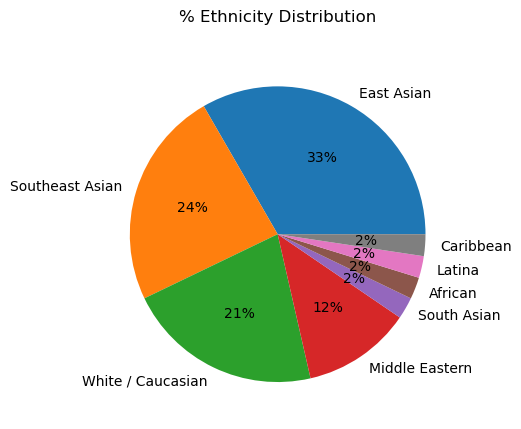

In [11]:
#explorative code for plots
import matplotlib.pyplot as plt

eth_labels = [
    'East Asian', 
    'Southeast Asian', 
    'White / Caucasian', 
    'Middle Eastern', 
    'South Asian', 
    'African', 
    'Latina',
    'Caribbean'
]

plt.pie(df['ethnicity'].value_counts(),labels = eth_labels, autopct='%1.0f%%', textprops={'fontsize': '10'}, radius=1.0)
plt.title('% Ethnicity Distribution', fontsize = 12, pad=20)
plt.savefig('ethnicity_distribution.png', dpi=300, bbox_inches='tight')

#autopct for displaying, adjusting % values

In [12]:
#here I am defining the categorical labels for demographic and health literacy variables 
edu_labels = [
    "Some university/ post-secondary, no degree", 
    "Bachelor's degree", 
    "High school degree or equivalent", 
    "Doctorate or professional degree", 
    "Master's degree"]

sex_active_labels=[
    "No", 
    "Yes", 
    "Prefer not to say"]


health_literacy_labels=[
    "Medium", 
    "High", 
    "Low","Expert", "Non-existent"]

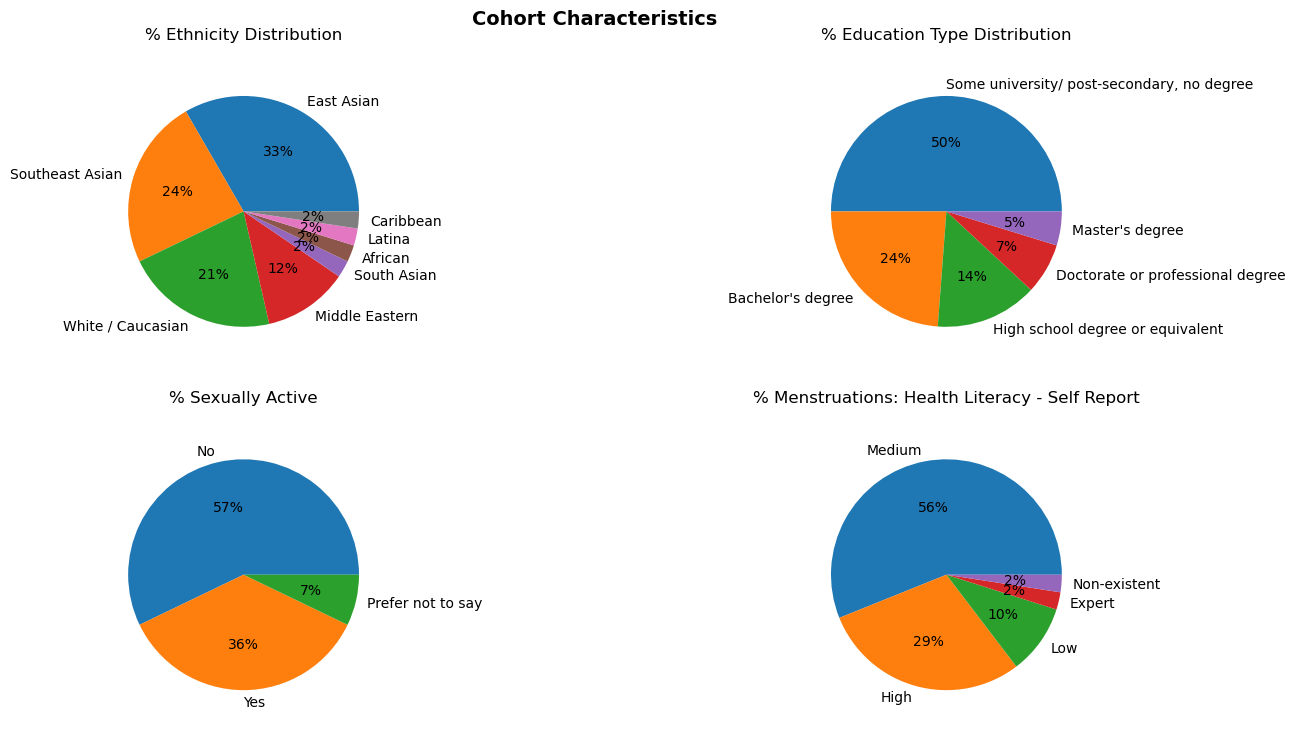

In [13]:
#running a plot inlcuding ethnicity, education, information about being or not sexually active, 
#and health literacy

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 7), layout='constrained') #prompt

fig.suptitle(
    "Cohort Characteristics",
    fontsize=14,
    weight="bold",
    y=1.02,
)

# Plot 1
ax1.pie(df['ethnicity'].value_counts(), labels=eth_labels, radius=1.0, autopct='%1.0f%%')
ax1.set_title('% Ethnicity Distribution', fontsize = 12, pad=20)

# Plot 2
ax2.pie(df['education'].value_counts(), labels=edu_labels, radius=1.0, autopct='%1.0f%%')
ax2.set_title('% Education Type Distribution', fontsize = 12, pad=20)

ax3.pie(df['sexually_active'].value_counts(), labels=sex_active_labels, radius=1.0, autopct='%1.0f%%')
ax3.set_title('% Sexually Active', fontsize = 12, pad=20)

ax4.pie(df['self_report_menstrual_health_literacy'].value_counts(), labels=health_literacy_labels, radius=1.0, autopct='%1.0f%%')
ax4.set_title('% Menstruations: Health Literacy - Self Report', fontsize = 12, pad=20)

fig.get_layout_engine().set(hspace=0.1)

plt.savefig('demographics_and_literacy.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
#one variable that is missing and that is of interest is age
#for the calculation of study particpants age I have used the recruitment year, namely 2022
df["age"]=(2022 -df["birth_year"])
#df["age"].dtype

In [15]:
print(df["age"].max(),df["age"].min())

29 18


In [16]:
#what about age of first menarche?
print(df["age_of_first_menarche"].max(),df["age_of_first_menarche"].min())

15 10


In [17]:
print(df["age_of_first_menarche"].mean().round(2))

11.93


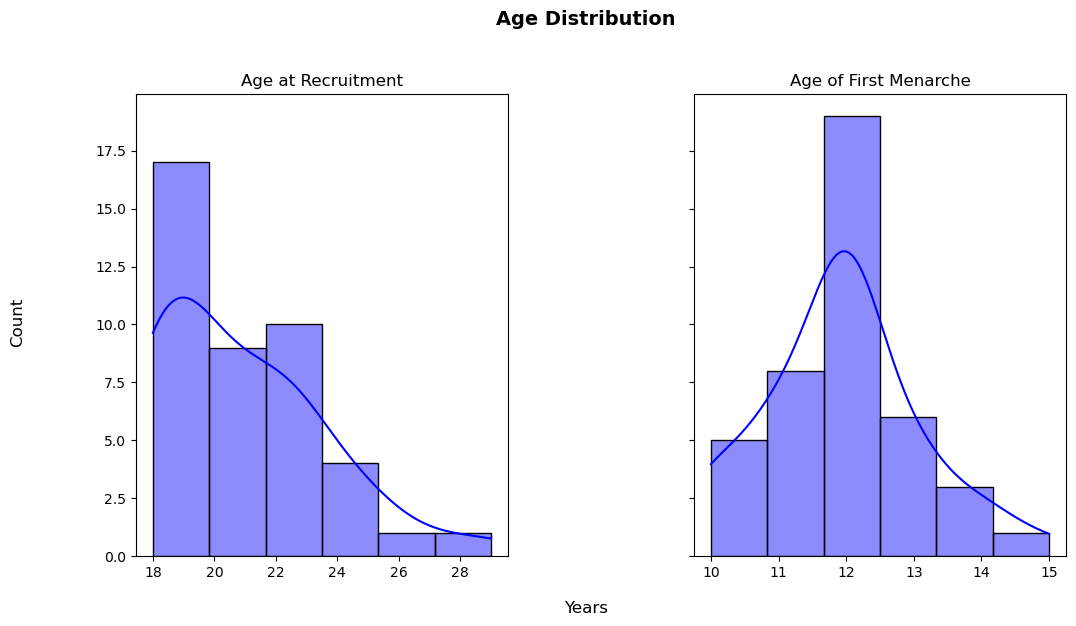

In [18]:
#histogram plots
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plt.subplots_adjust(wspace=0.5, hspace=0.5)

fig.suptitle(
    "Age Distribution",
    fontsize=14,
    weight="bold",
    y=1.02,
)

histo_1=sns.histplot(df['age'].dropna(), bins=6, 
               alpha=0.45, color='blue', kde=True, ax=axes[0])
#histo_1.set(ylabel=None)
histo_1.set_title('Age at Recruitment')
histo_1.set(xlabel=None)
histo_1.set(ylabel="")


histo_2=sns.histplot(df['age_of_first_menarche'].dropna(), bins=6, 
               alpha=0.45, color='blue', kde=True, ax=axes[1])
#histo_1.set(ylabel=None)
histo_2.set_title('Age of First Menarche')
histo_2.set(xlabel=None)

fig.supxlabel("Years")
fig.supylabel("Count")

plt.savefig('Age_Distributions.png', dpi=300, bbox_inches='tight')

In [19]:
#here I work on the second dataset of interest, namely hormones_and_selfreport
import pandas as pd
df_h = pd.read_csv(
    'hormones_and_selfreport.csv')
df_h.head()

,id,study_interval,is_weekend,day_in_study,phase,lh,estrogen,pdg,flow_volume,flow_color,...,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating
0,1,2022,True,1,Follicular,2.9,94.2,NaN,Not at all,Not at all,...,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
1,1,2022,False,2,Follicular,1.2,226.3,NaN,Not at all,Not at all,...,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
2,1,2022,False,3,Follicular,3.5,276.8,NaN,Not at all,Not at all,...,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
3,1,2022,False,4,Fertility,1.8,322.1,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
4,1,2022,False,5,Fertility,4.6,244.9,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,High,High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little


In [20]:
#checking on available variables and type
df_h.dtypes

id                  int64
study_interval      int64
is_weekend           bool
day_in_study        int64
phase              object
lh                float64
estrogen          float64
pdg               float64
flow_volume        object
flow_color         object
appetite           object
exerciselevel      object
headaches          object
cramps             object
sorebreasts        object
fatigue            object
sleepissue         object
moodswing          object
stress             object
foodcravings       object
indigestion        object
bloating           object
dtype: object

In [21]:
#a key question is: which and how many are the phases as defined by the study?
df_h["phase"].unique()

array(['Follicular', 'Fertility', 'Luteal', 'Menstrual', nan],
      dtype=object)

In [22]:
#how many missing values in absolute numbers per each variable are present?
df_h.isnull().sum() #only one missing value for phases...

id                   0
study_interval       0
is_weekend           0
day_in_study         0
phase                1
lh                 320
estrogen           321
pdg               3795
flow_volume       2470
flow_color        2465
appetite          2329
exerciselevel     2329
headaches         2331
cramps            2332
sorebreasts       2332
fatigue           2328
sleepissue        2330
moodswing         2339
stress            2332
foodcravings      2332
indigestion       2334
bloating          2331
dtype: int64

In [23]:
#and how many missing values in %?
df_h.isnull().sum()
round((df_h.isnull().sum() / len(df_h) * 100), 2)

id                 0.00
study_interval     0.00
is_weekend         0.00
day_in_study       0.00
phase              0.02
lh                 5.65
estrogen           5.67
pdg               67.06
flow_volume       43.65
flow_color        43.56
appetite          41.16
exerciselevel     41.16
headaches         41.19
cramps            41.21
sorebreasts       41.21
fatigue           41.14
sleepissue        41.17
moodswing         41.33
stress            41.21
foodcravings      41.21
indigestion       41.24
bloating          41.19
dtype: float64

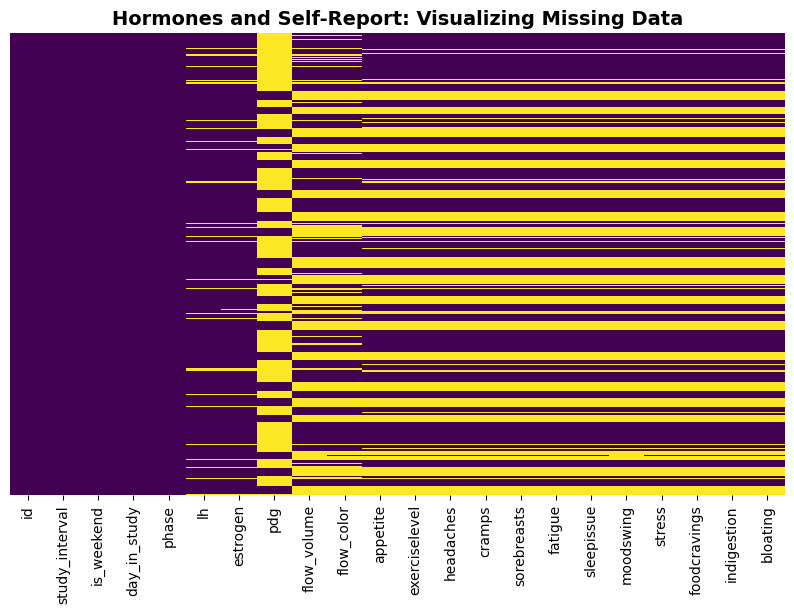

In [24]:
#visualizing missings 
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df_h.isna(), cbar=False, cmap='viridis', yticklabels=False, ax=ax)
ax.set_title(
    "Hormones and Self-Report: Visualizing Missing Data",
    fontsize=14,
    weight="bold"
)
plt.savefig('Missing Data.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Users consistently omit information across specific time windows, resulting in 
# large yellow blocks that overlap across all daily symptom columns.

# In agreement with the calculated missing percentages, columns like estrogen and lh 
# (luteinizing hormone) show fewer gaps. This suggests higher user engagement in 
# tracking hormonal data compared to daily physical or mood symptoms.

# Additionally, data might be missing simply because the symptom or biological marker 
# is absent. For instance, pdg (pregnanediol glucuronide) is a urinary progesterone 
# metabolite that only becomes biologically relevant in a restricted phase of the luteal phase.

#Next, to understand better the nature of missing data let's for instance compare the missing values in the menstrual phase 
#(the "actual" period) and the luteal phase (normally with fewer symptoms) 
#and let's do that for cramps; cramps are in fact typical symptoms of the menstrual phase.
phases_to_drop = ["Follicular", "Fertility", "Luteal"]
df_menstrual = df_h[~df_h['phase'].isin(phases_to_drop)] 
menstrual_missing_abs = df_menstrual['cramps'].isna().sum()
menstrual_missing = (df_menstrual['cramps'].isna().mean() * 100).round(2)
print("missing %:", menstrual_missing, "| missing absolute number:", menstrual_missing_abs)

missing %: 40.93 | missing absolute number: 442


In [26]:
phases_to_drop_2 = ["Follicular", "Fertility", "Menstrual"]
df_luteal = df_h[~df_h['phase'].isin(phases_to_drop_2)]
luteal_missing_abs = df_luteal['cramps'].isna().sum()
luteal_missing = (df_luteal['cramps'].isna().mean() * 100).round(2)
print("missing %:", luteal_missing, "| missing absolute number:", luteal_missing_abs)

missing %: 41.56 | missing absolute number: 795


In [27]:
print("Total menstrual rows:", df_menstrual.shape[0])
print("Total luteal rows:", df_luteal.shape[0])

Total menstrual rows: 1080
Total luteal rows: 1913


In [28]:
#The two phases have very comparable rates of missings. The difference in absolute numbers can be explained by the fact that 
#the luteal phase lasts longer than the menstrual phase. 
#This implies that users likely logged and fed the app 
#with information relative to pain independently of the actual pain they were experiencing...
#There is likely no biological pattern driving user behavior when reporting pain.
#So the missing values can be safely left as NaN...or at least imputation is not strictly required. 

In [29]:
#the aim of the next session is to convert the levels of the different symptoms into integers (i.e., ordinal encoding),
#so that I can eventually calculate a pain score, in particular two types of pain scores (see next sections)
#here I sart to work on symptoms, let's take headaches variable and "inspect" it
df_h["headaches"].unique()

array(['High', 'Very High', 'Very Low/Little', nan, 'Moderate',
       'Not at all', 'Low', '2', '5', '3', '4'], dtype=object)

In [30]:
#since for "headaches" there are already values 2,3,4 and 5 presumably corresponding already to levels as listed above, 
#I will replace them into numbers (int) 2,3,4,and 5, respectively
df_h['headaches'] = df_h['headaches'].replace({"2":2, "3":3, "4":4, "5":5})
df_h["headaches"].unique()

array(['High', 'Very High', 'Very Low/Little', nan, 'Moderate',
       'Not at all', 'Low', 2, 5, 3, 4], dtype=object)

In [31]:
#before to proceed with headaches ordinal encoding, I define a numeric scale corresponding to the different symptoms levels 
#that can be used for all the other symptoms variables 
scale = {
    "Not at all": 1,
    "Very Low/Little": 2,
    "Low": 3,
    "Moderate": 4,
    "High": 5,
    "Very High": 6,
}

df_h["headaches"] = df_h["headaches"].replace(scale)
df_h["headaches"] = pd.to_numeric(df_h["headaches"], errors="coerce")
print(sorted(df_h["headaches"].dropna().unique()))

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0]


/var/folders/_s/p9gxcg_901xc40yd_syh_7_w0000gn/T/ipykernel_5396/1823058413.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_h["headaches"] = df_h["headaches"].replace(scale)


In [32]:
#now I check on scale associated to each variable, to make sure I can use the scale as defined above
print(
    "cramps:", df_h["cramps"].unique(), 
    "| sorebreasts:", df_h["sorebreasts"].unique(), 
    "| fatigue:", df_h["fatigue"].unique(), 
    "| sleepissue:", df_h["sleepissue"].unique(), 
    "| moodswing:", df_h["moodswing"].unique(), 
    "| stress:", df_h["stress"].unique(), 
    "| foodcravings:", df_h["foodcravings"].unique(), 
    "| indigestion:", df_h["indigestion"].unique(), 
    "| bloating:", df_h["bloating"].unique()
)

cramps: ['Very Low/Little' nan 'Moderate' 'High' 'Not at all' 'Low' 'Very High'] | sorebreasts: ['Very Low/Little' nan 'Low' 'Moderate' 'Not at all' 'High' 'Very High'] | fatigue: ['High' 'Very High' 'Moderate' 'Low' 'Very Low/Little' nan 'Not at all'] | sleepissue: ['Low' 'Very High' 'High' 'Moderate' 'Very Low/Little' nan 'Not at all'] | moodswing: ['Very Low/Little' 'Low' nan 'Not at all' 'Moderate' 'High' 'Very High'] | stress: ['Moderate' 'Low' 'Very Low/Little' nan 'High' 'Very High' 'Not at all'
 '2' '3' '1'] | foodcravings: ['Very Low/Little' nan 'Low' 'Not at all' 'Moderate' 'High' 'Very High'] | indigestion: ['Very Low/Little' nan 'Low' 'Not at all' 'Moderate' 'High' 'Very High'] | bloating: ['Very Low/Little' nan 'Not at all' 'Moderate' 'High' 'Low' 'Very High']


In [33]:
#the different variables symptoms share the same levels

In [34]:
#I will run a loop on symptoms 
symptoms = [
    "cramps",
    "sorebreasts",
    "fatigue",
    "sleepissue",
    "moodswing",
    "stress",
    "foodcravings",
    "indigestion",
    "bloating"]
print(symptoms)

['cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']


In [35]:

#the numeric scale I want to implement, for ordinal encoding of symptoms variables is again the following:

#'Not at all' =1
#Low =2
#Very Low/Little=3
#Moderate=4
#High=5
#Very high=6



In [36]:
#at this point i can implement a loop for buidling the new scale per each symptom
for s in symptoms:
    df_h[s] = df_h[s].replace(scale)
    df_h[s] = pd.to_numeric(df_h[s], errors="coerce")

/var/folders/_s/p9gxcg_901xc40yd_syh_7_w0000gn/T/ipykernel_5396/3423324769.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_h[s] = df_h[s].replace(scale)


In [37]:
for s in symptoms:
    print(s, sorted(df_h[s].dropna().unique()))

cramps [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
sorebreasts [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
fatigue [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
sleepissue [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
moodswing [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
stress [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
foodcravings [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
indigestion [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
bloating [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]


In [38]:
#in these section I will work on pain scores
#I will focus on an all pain score which includes all the symptoms and on a score relative to the menstrual phase 
#and which includes: cramps, fatigue and blaoting (which are typical symptoms of the menstrual phase)

#so the two scores are:

#"menstrual_pain_score"

#and

#"all_pain_score"


In [39]:
#initially run the following code, however this is NOT A GOOD IDEA, I end up with scores 0! Which may be a clear artifact! 
#df_h[["cramps", "fatigue", "bloating"]] = df_h[["cramps", "fatigue", "bloating"]].fillna(0)
#df_h["menstrual_pain_score"] = df_h["cramps"] + df_h["fatigue"] + df_h["bloating"]
#df_h

In [40]:
# No fillna(0) needed! This keeps true zeroes separate from missing data
df_h["menstrual_pain_score"] = df_h[["cramps", "fatigue", "bloating"]].sum(axis=1, min_count=1)

In [41]:
df_h["all_pain_score"] = df_h[["cramps","headaches",
    "sorebreasts",
    "fatigue",
    "sleepissue",
    "moodswing",
    "stress",
    "foodcravings",
    "indigestion",
    "bloating" ]].sum(axis=1, min_count=1)
df_h 

,id,study_interval,is_weekend,day_in_study,phase,lh,estrogen,pdg,flow_volume,flow_color,...,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating,menstrual_pain_score,all_pain_score
0,1,2022,True,1,Follicular,2.9,94.2,NaN,Not at all,Not at all,...,2.0,5.0,3.0,2.0,4.0,2.0,2.0,2.0,9.0,29.0
1,1,2022,False,2,Follicular,1.2,226.3,NaN,Not at all,Not at all,...,2.0,5.0,6.0,2.0,4.0,2.0,2.0,2.0,9.0,33.0
2,1,2022,False,3,Follicular,3.5,276.8,NaN,Not at all,Not at all,...,2.0,6.0,6.0,2.0,3.0,2.0,2.0,2.0,10.0,32.0
3,1,2022,False,4,Fertility,1.8,322.1,NaN,Not at all,Not at all,...,2.0,5.0,6.0,2.0,3.0,2.0,2.0,2.0,9.0,28.0
4,1,2022,False,5,Fertility,4.6,244.9,NaN,Not at all,Not at all,...,2.0,5.0,5.0,2.0,3.0,2.0,2.0,2.0,9.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5654,50,2024,False,947,Luteal,4.6,70.7,2.8,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5655,50,2024,False,948,Luteal,5.8,87.0,7.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5656,50,2024,False,949,Luteal,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5657,50,2024,False,950,Menstrual,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
#I expect that menstrual pain to be associated with the highest menstrual pain score
#this would be importat in terms of biological plausibility of the current analysis! 

In [43]:
#to proceed, I need to understand first the contextual or relational "meaning" of day_in_study
#by definiton -->
#day_in_study: normalized day index starting from Day 1 of each participant’s study interval


df_h.groupby(["id", "phase","study_interval"])["day_in_study"].count()

#by running this line of code, I get the number of days users logged per phase per year, which is a cumulative value. 
#This explains why a single value can be even higher than 30 days...
#So, per each phase, we have: "logged" fertility days, "logged" follicular days, and so on.
#And I want to calculate the pain average across all individuals for each phase length, 
#this being defined as the sum of "logged" phase days.

id  phase       study_interval
1   Fertility   2022              20
    Follicular  2022              15
    Luteal      2022              38
    Menstrual   2022              17
2   Fertility   2022              20
                                  ..
50  Follicular  2024              16
    Luteal      2022              15
                2024              37
    Menstrual   2022              18
                2024              26
Name: day_in_study, Length: 247, dtype: int64

In [44]:
#Next I reorganize the data as follows implementing new average pain variables
phase_df = (
    df_h.groupby(["id", "phase"])
    .agg(
        total_days=("day_in_study", "count"),
        avg_pain_score=("menstrual_pain_score", "mean"),
        avg_pain_score_all=("all_pain_score", "mean"),
    )
    .reset_index()
)
phase_df

,id,phase,total_days,avg_pain_score,avg_pain_score_all
0,1,Fertility,20,6.526316,21.473684
1,1,Follicular,15,6.769231,22.769231
2,1,Luteal,38,6.205882,20.470588
3,1,Menstrual,17,7.000000,21.857143
4,2,Fertility,20,6.400000,20.050000
...,...,...,...,...,...
163,49,Menstrual,10,9.000000,30.000000
164,50,Fertility,53,10.172414,33.448276
165,50,Follicular,44,10.333333,35.444444
166,50,Luteal,52,10.000000,33.000000


In [45]:
#rapid check on missings
phase_df.isna().sum()

id                    0
phase                 0
total_days            0
avg_pain_score        0
avg_pain_score_all    0
dtype: int64

In [46]:
phase_df.describe().round(2)

,id,total_days,avg_pain_score,avg_pain_score_all
count,168.00,168.00,168.00,168.00
mean,25.64,33.68,8.16,26.78
std,15.21,18.39,2.39,7.57
min,1.00,6.00,3.00,10.00
25%,12.00,19.00,6.62,22.46
50%,25.00,31.00,8.06,26.57
75%,40.00,44.25,9.66,31.02
max,50.00,100.00,13.38,43.15


In [47]:
phase_df.groupby("phase") ["avg_pain_score"].median().round(2)

phase
Fertility     7.65
Follicular    7.21
Luteal        7.81
Menstrual     9.56
Name: avg_pain_score, dtype: float64

In [48]:
phase_df["phase"].unique()

array(['Fertility', 'Follicular', 'Luteal', 'Menstrual'], dtype=object)

Text(0.5, 0, 'Phase')

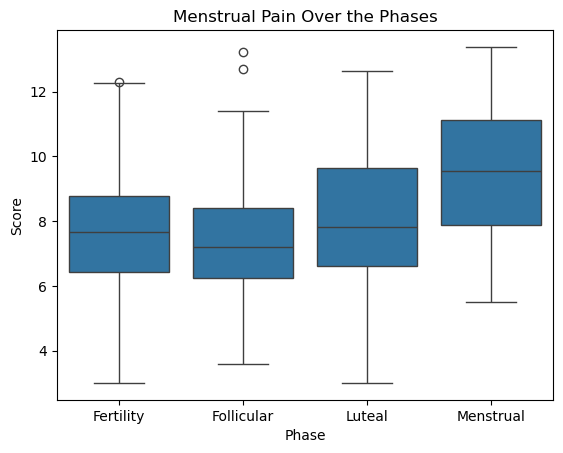

In [49]:
#boxplots 
ax_0 = sns.boxplot(phase_df, x="phase", y="avg_pain_score")
ax_0.set_title('Menstrual Pain Over the Phases')
ax_0.set_ylabel('Score')
ax_0.set_xlabel('Phase')

In [50]:
phase_df.groupby("phase") ["avg_pain_score_all"].median().round(2)

phase
Fertility     25.81
Follicular    24.85
Luteal        26.61
Menstrual     29.29
Name: avg_pain_score_all, dtype: float64

Text(0.5, 0, 'Phase')

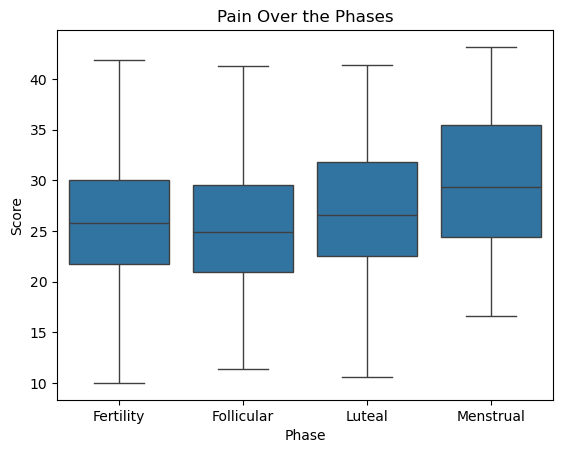

In [51]:
ax_1= sns.boxplot(phase_df, x="phase", y="avg_pain_score_all")
ax_1.set_title('Pain Over the Phases')
ax_1.set_ylabel('Score')
ax_1.set_xlabel('Phase')

In [52]:
#the first figure,of the two above, seems to show more pronounced differences for the pain associated to mestrual phase as it does in
#the second graph. However, that is not a "fair" comparison, as we need to align these graphs and use the same scale

In [53]:
#first I want to display the different phases in the natural or biological order...
phase_df_ordered = phase_df.copy()

from pandas.api.types import CategoricalDtype
cycle_order = ['Menstrual', 'Follicular', 'Fertility', 'Luteal']
cat_type = CategoricalDtype(categories=cycle_order, ordered=True)

phase_df_ordered['phase'] = phase_df_ordered['phase'].astype(cat_type)

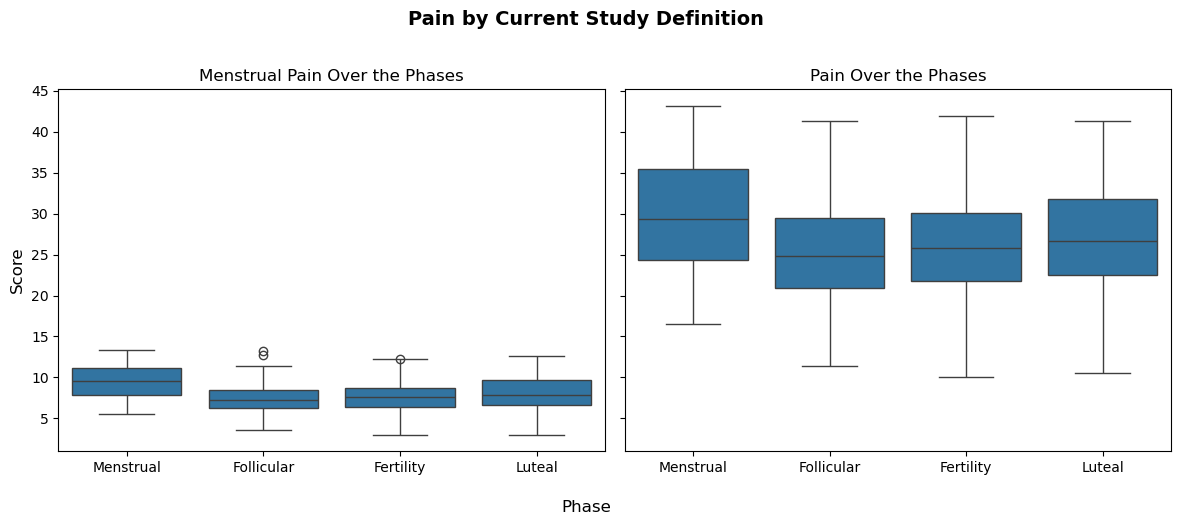

In [54]:
#in this graph the "fair" comparison
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True) 

fig.suptitle(
    "Pain by Current Study Definition",
    fontsize=14,
    weight="bold",
    y=1.02,
)

sns.boxplot(data=phase_df_ordered, x="phase", y="avg_pain_score", ax=axes[0])
axes[0].set_title("Menstrual Pain Over the Phases")
axes[0].set_ylabel('Score')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

sns.boxplot(data=phase_df_ordered, x="phase", y="avg_pain_score_all", ax=axes[1])
axes[1].set_title("Pain Over the Phases")
axes[1].set_xlabel('')

fig.supxlabel("Phase")
fig.supylabel("Score")

plt.tight_layout()

plt.savefig('Pain Over the Phases_final.png', dpi=300, bbox_inches='tight') #tested different graph titles...

plt.show()

In [55]:
#as anticipated, pain for both definitions and calculations tends to be higher in the Menstrual phase 
#caveat: no statistics provided, though! 

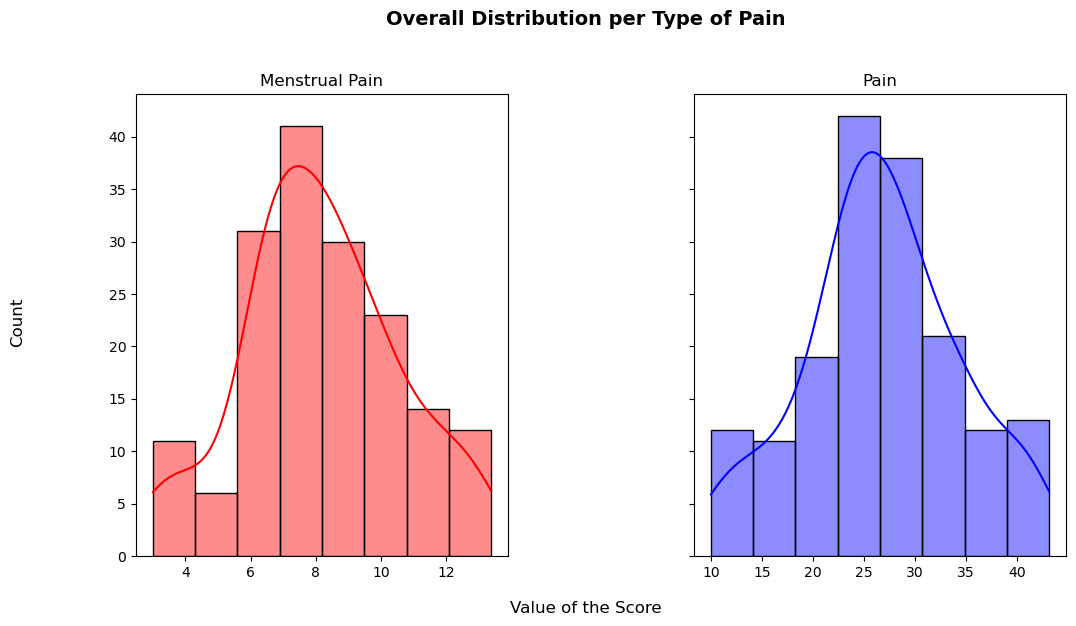

In [56]:
#let's check on pain scores distribution:
#distribution across all phases

import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plt.subplots_adjust(wspace=0.5, hspace=0.5)



histo_3=sns.histplot(phase_df['avg_pain_score'].dropna(), bins=8, 
               alpha=0.45, color='red', kde=True, ax=axes[0])
#histo_3.set(ylabel=None)
histo_3.set_title('Menstrual Pain')
histo_3.set(xlabel=None)
histo_3.set(ylabel="")


histo_4=sns.histplot(phase_df['avg_pain_score_all'].dropna(), bins=8, 
               alpha=0.45, color='blue', kde=True, ax=axes[1])
#histo_1.set(ylabel=None)
histo_4.set_title('Pain')
histo_4.set(xlabel=None)

fig.supxlabel("Value of the Score")
fig.supylabel("Count")
fig.suptitle(
    "Overall Distribution per Type of Pain", fontsize=14, weight="bold", y=1.02
)

plt.savefig('Overall Distribution per Type of Pain_final.png', dpi=300, bbox_inches='tight') #tested different graph titles...

In [57]:
#here I generate a menstrual subset
menstrual_subset = phase_df[phase_df['phase'] == 'Menstrual'][['id', 'avg_pain_score', 'avg_pain_score_all']].reset_index(drop=True)
menstrual_subset.head()

,id,avg_pain_score,avg_pain_score_all
0,1,7.000000,21.857143
1,2,8.375000,21.250000
2,3,6.625000,18.500000
3,4,9.416667,22.083333
4,6,7.238095,24.952381


In [58]:
#again rapid check on missing values
menstrual_subset.isna().sum()

id                    0
avg_pain_score        0
avg_pain_score_all    0
dtype: int64

In [59]:
menstrual_subset.describe().round(2) 

,id,avg_pain_score,avg_pain_score_all
count,42.00,42.00,42.00
mean,25.64,9.59,29.70
std,15.35,2.20,7.18
min,1.00,5.50,16.57
25%,12.25,7.89,24.39
50%,25.00,9.56,29.29
75%,39.75,11.12,35.48
max,50.00,13.38,43.15


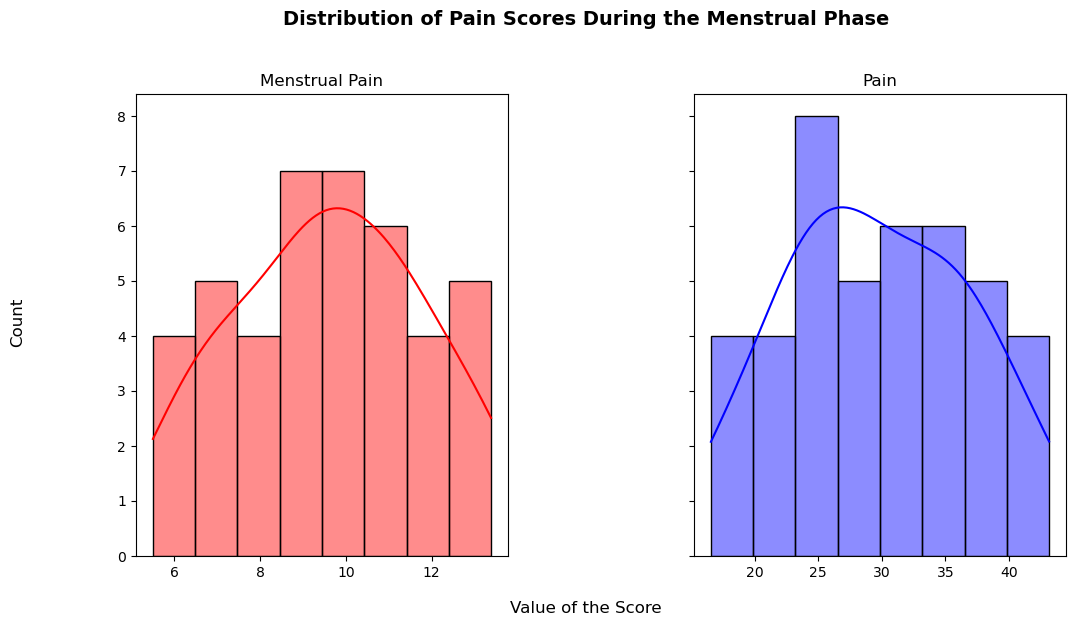

In [60]:
#pain scores distribution, this time across the menstrual phase only! 
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
plt.subplots_adjust(wspace=0.5, hspace=0.5)



histo_3=sns.histplot(menstrual_subset['avg_pain_score'].dropna(), bins=8, 
               alpha=0.45, color='red', kde=True, ax=axes[0])
#histo_3.set(ylabel=None)
histo_3.set_title('Menstrual Pain')
histo_3.set(xlabel=None)
histo_3.set(ylabel="")


histo_4=sns.histplot(menstrual_subset['avg_pain_score_all'].dropna(), bins=8, 
               alpha=0.45, color='blue', kde=True, ax=axes[1])
#histo_1.set(ylabel=None)
histo_4.set_title('Pain')
histo_4.set(xlabel=None)

fig.supxlabel("Value of the Score")
fig.supylabel("Count")

fig.suptitle("Distribution of Pain Scores During the Menstrual Phase", fontsize=14, weight='bold', y=1.02)

plt.savefig('Distribution of Pain Scores During the Menstrual Phase_final.png', dpi=300, bbox_inches='tight') #tested different graph titles...

In [61]:
#active_zone_minutes.csv
#description of the authors:
#This file contains the time spent in different heart rate zones, which Fitbit uses to assess exercise intensity. 
#Active Zone Minutes are awarded based on time spent in the fat burn, cardio, and peak heart rate zones. Columns include:

In [62]:
df_azm= pd.read_csv(
    'active_zone_minutes.csv')
df_azm.tail()

,id,study_interval,is_weekend,day_in_study,timestamp,heart_zone_id,total_minutes
154477,50,2024,True,946,18:36:00,CARDIO,2
154478,50,2024,True,946,18:35:00,CARDIO,2
154479,50,2024,True,946,18:34:00,CARDIO,2
154480,50,2024,True,946,18:33:00,CARDIO,2
154481,50,2024,True,946,18:32:00,CARDIO,2


In [63]:
df_azm.isna().sum() #no missings!

id                0
study_interval    0
is_weekend        0
day_in_study      0
timestamp         0
heart_zone_id     0
total_minutes     0
dtype: int64

In [64]:
df_azm["id"].nunique()
#42 individuals (as anticipated)

42

In [65]:
#which are the heart zones?
df_azm["heart_zone_id"].unique() #this is the quality of exercise, or intesity

array(['FAT_BURN', 'CARDIO', 'PEAK'], dtype=object)

In [66]:
#individual entering the different zones at least once
print(df_azm.groupby('heart_zone_id')['id'].nunique())

heart_zone_id
CARDIO      42
FAT_BURN    42
PEAK        15
Name: id, dtype: int64


In [67]:
#these numbers mean that every single person who "entered" a FAT_BURN session also "entered" a CARDIO session

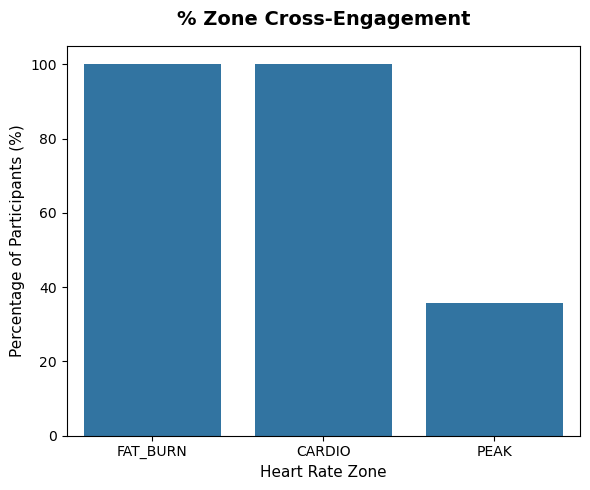

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns


zones = ['FAT_BURN', 'CARDIO', 'PEAK']
counts = [42, 42, 15]
total_users = 42
percentages = [(c / total_users) * 100 for c in counts]


plt.figure(figsize=(6, 5))

ax = sns.barplot(x=zones, y=percentages) 


plt.title('% Zone Cross-Engagement', fontsize=14, pad=15, weight='bold')
plt.ylabel('Percentage of Participants (%)', fontsize=11)
plt.xlabel('Heart Rate Zone', fontsize=11)
#plt.ylim(0, 115) # Leave some space at the top for labels



#sns.despine() 
plt.tight_layout()

plt.savefig('Zone Cross-Engagement.png', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
#users crossed over into multiple categories...! (cross-engagement)
print(percentages)

[100.0, 100.0, 35.714285714285715]


In [70]:
#here I intend to calculate a score  that sums up the activity as expression of the intensity/zone 
#I will use this score to see whether it correlates with pain (as defined above)

In [71]:
df_azm_1= df_azm.groupby(['id', 'heart_zone_id']).size()
df_azm_1.head()

id  heart_zone_id
1   CARDIO            162
    FAT_BURN          814
    PEAK                7
2   CARDIO             63
    FAT_BURN         1176
dtype: int64

In [72]:
df_azm_1.index.get_level_values("id").nunique()

42

In [73]:
#df_azm_1.dtypes

In [74]:
#weighing the zone contribution #1...DO NOT RUN
#df_azm_1["exercise_score"]=(df_azm_1["FAT_BURN"] * 1)+(df_azm_1["CARDIO"] * 3)+(df_azm_1["PEAK"] * 6)
#df_azm_1.head()

In [75]:
df_azm_1= df_azm.groupby(['id', 'heart_zone_id']).size().unstack(fill_value=0)
df_azm_1["exercise_score"]=(df_azm_1["FAT_BURN"] * 1)+(df_azm_1["CARDIO"] * 3)+(df_azm_1["PEAK"] * 6)
df_azm_1.head()

heart_zone_id,CARDIO,FAT_BURN,PEAK,exercise_score
id,,,,
1,162,814,7,1342
2,63,1176,0,1365
3,275,2616,0,3441
4,190,2198,0,2768
6,301,1882,13,2863


In [76]:
df_azm_1.isna().sum()

heart_zone_id
CARDIO            0
FAT_BURN          0
PEAK              0
exercise_score    0
dtype: int64

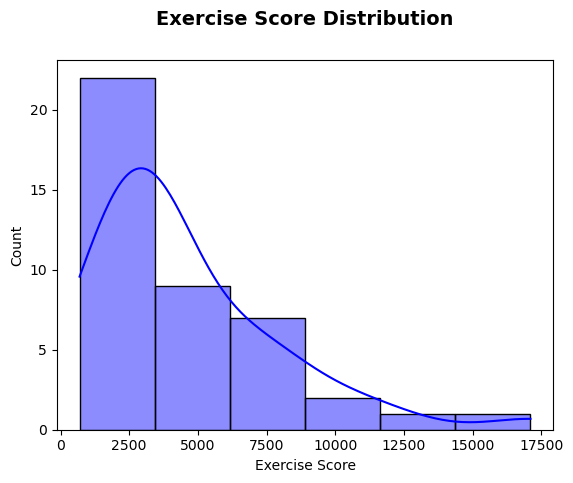

In [77]:
histo_es = sns.histplot(
    df_azm_1["exercise_score"].dropna(),
    bins=6,
    alpha=0.45,
    color="blue",
    kde=True,
)


histo_es.set_title("Exercise Score Distribution", fontsize=14, pad=20, weight='bold', y=1.02)
histo_es.set(xlabel="Exercise Score", ylabel="Count")

# Display the plot
plt.show()

In [78]:
#To determine whether, and to what extent, physical activity levels correlate with self-reported pain (as defined)
#by means OLS, both data from the azm and symptom datasets have to be merged by participant id 
#to merge the two datasets I have to turn the index "id" in  df_azm_1 into a normal column

In [79]:
df_azm_1_reset = df_azm_1.reset_index()
df_azm_1_reset.head()

heart_zone_id,id,CARDIO,FAT_BURN,PEAK,exercise_score
0,1,162,814,7,1342
1,2,63,1176,0,1365
2,3,275,2616,0,3441
3,4,190,2198,0,2768
4,6,301,1882,13,2863


In [80]:
#after these all rearrangements let's check on the # id
df_azm_1_reset["id"].nunique() 
#42, that looks good

42

In [81]:
analysis_df = pd.merge(df_azm_1_reset, menstrual_subset, on="id", how="inner")
analysis_df.head()

,id,CARDIO,FAT_BURN,PEAK,exercise_score,avg_pain_score,avg_pain_score_all
0,1,162,814,7,1342,7.000000,21.857143
1,2,63,1176,0,1365,8.375000,21.250000
2,3,275,2616,0,3441,6.625000,18.500000
3,4,190,2198,0,2768,9.416667,22.083333
4,6,301,1882,13,2863,7.238095,24.952381


In [82]:
analysis_df["id"].nunique() 
#the merge keeps the expected number of id

42

In [83]:
analysis_df.isna().sum()

id                    0
CARDIO                0
FAT_BURN              0
PEAK                  0
exercise_score        0
avg_pain_score        0
avg_pain_score_all    0
dtype: int64

In [84]:
#correlation: Pearson (not critical as I run also OLS)

In [85]:
#corr_pain=analysis_df["exercise_score"].corr(analysis_df["avg_pain_score"])
#corr_pain_all = analysis_df["exercise_score"].corr(
    #analysis_df["avg_pain_score_all"]
#)
#print(f"Pearson r Exercise vs. Core Menstrual Pain:  {corr_pain:.3f}")
#print(f"Pearson r Exercise vs. All Combined Symptoms: {corr_pain_all:.3f}")

In [86]:
import statsmodels.api as sm
#avg_pain_score vs exercise_score

X = analysis_df["exercise_score"]
y = analysis_df["avg_pain_score"]
X_with_constant = sm.add_constant(X)


model = sm.OLS(y, X_with_constant).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         avg_pain_score   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.2048
Date:                Sun, 19 Jul 2026   Prob (F-statistic):              0.653
Time:                        13:55:04   Log-Likelihood:                -92.060
No. Observations:                  42   AIC:                             188.1
Df Residuals:                      40   BIC:                             191.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.3812      0.573     16.

In [87]:
#avg_pain_score_all vs exercise_score
X_all = analysis_df["exercise_score"]
y_all = analysis_df["avg_pain_score_all"]
X_with_constant_all = sm.add_constant(X)


model_all = sm.OLS(y, X_with_constant).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         avg_pain_score   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.2048
Date:                Sun, 19 Jul 2026   Prob (F-statistic):              0.653
Time:                        13:55:04   Log-Likelihood:                -92.060
No. Observations:                  42   AIC:                             188.1
Df Residuals:                      40   BIC:                             191.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.3812      0.573     16.

In [88]:
#no correlation at all...but it probably makes sense to fix the skewness of exercixe score

In [89]:
#fixing the skewness of exercixe score
import numpy as np
analysis_df["log_exercise_score"] = np.log(analysis_df["exercise_score"])

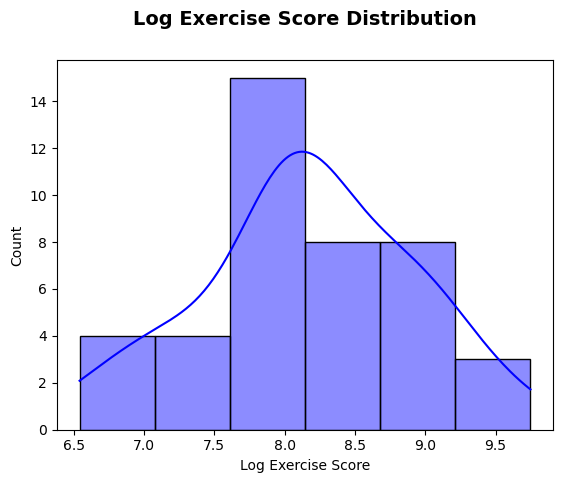

In [90]:
#new histogram for log exercise
histo_es = sns.histplot(
    analysis_df["log_exercise_score"].dropna(),
    bins=6,
    alpha=0.45,
    color="blue",
    kde=True,
)


histo_es.set_title("Log Exercise Score Distribution", fontsize=14, pad=20, weight='bold', y=1.02)
histo_es.set(xlabel="Log Exercise Score", ylabel="Count")

# Display the plot
plt.show()

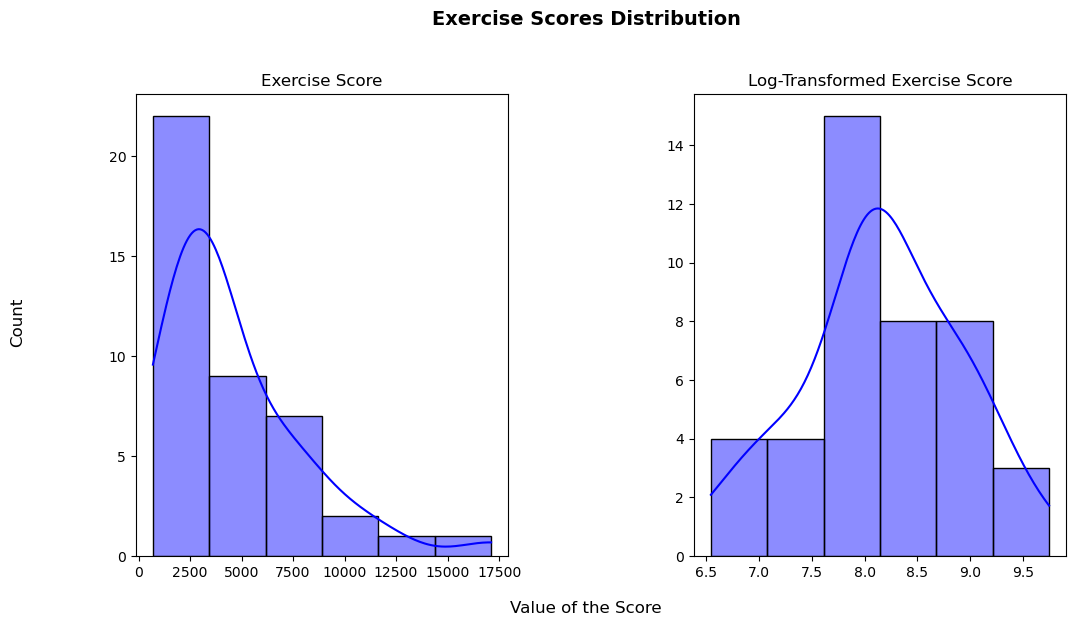

In [91]:
#let#s visualize both scores distributions in one panel
#excercise scores distribution 
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plt.subplots_adjust(wspace=0.5, hspace=0.5)



histo_7=sns.histplot(df_azm_1["exercise_score"].dropna(), bins=6, 
               alpha=0.45, color='blue', kde=True, ax=axes[0])

histo_7.set_title('Exercise Score')
histo_7.set(xlabel="")
histo_7.set(ylabel="")


histo_8=sns.histplot(analysis_df['log_exercise_score'].dropna(), bins=6, 
               alpha=0.45, color='blue', kde=True, ax=axes[1])

histo_8.set_title('Log-Transformed Exercise Score')
histo_8.set(xlabel="")
histo_8.set(ylabel="")


fig.supxlabel("Value of the Score")
fig.supylabel("Count")


fig.suptitle("Exercise Scores Distribution", fontsize=14, weight='bold', y=1.02)

plt.savefig('Exercise Scores_Final.png', dpi=300, bbox_inches='tight')

In [92]:
import numpy as np
import statsmodels.api as sm


X = analysis_df["log_exercise_score"]
y = analysis_df["avg_pain_score"]
X_with_constant = sm.add_constant(X)


log_model = sm.OLS(y, X_with_constant).fit()
print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:         avg_pain_score   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                    0.4610
Date:                Sun, 19 Jul 2026   Prob (F-statistic):              0.501
Time:                        13:55:04   Log-Likelihood:                -91.927
No. Observations:                  42   AIC:                             187.9
Df Residuals:                      40   BIC:                             191.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  7.0177      3

In [93]:
# no correlation, look at R and pvalue for instance!

In [94]:
import numpy as np
import statsmodels.api as sm


X_all = analysis_df["log_exercise_score"]
y_all= analysis_df["avg_pain_score_all"]
X_with_constant_all = sm.add_constant(X_all)


log_model_all = sm.OLS(y_all, X_with_constant_all).fit()
print(log_model_all.summary())

                            OLS Regression Results                            
Dep. Variable:     avg_pain_score_all   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.2897
Date:                Sun, 19 Jul 2026   Prob (F-statistic):              0.593
Time:                        13:55:04   Log-Likelihood:                -141.70
No. Observations:                  42   AIC:                             287.4
Df Residuals:                      40   BIC:                             290.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 23.0310     12

In [95]:
#the same as above, no correlation, look at R and pvalue

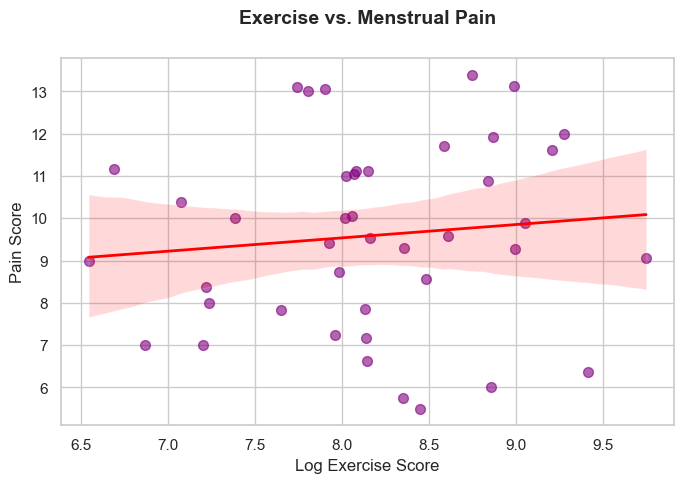

In [96]:
#representative plot 
import matplotlib.pyplot as plt
import seaborn as sns



sns.set_theme(style="whitegrid")


fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Plot directly on 'ax'
sns.regplot(
    data=analysis_df,
    x="log_exercise_score",
    y="avg_pain_score",
    color="purple",
    scatter_kws={"alpha": 0.6, "s": 50},  
    line_kws={"color": "red", "lw": 2},  
    ax=ax,
)

ax.set_title("Exercise vs. Menstrual Pain", fontsize=14, weight="bold", pad=20, y=1.02)
ax.set_xlabel("Log Exercise Score", fontsize=12)
ax.set_ylabel("Pain Score", fontsize=12)

plt.tight_layout()
plt.savefig("Exercise_vs_Pain_Analysis_Final.png", dpi=300)